In [ ]:
# Deep Learning Optimization: MLflow & Ray Tune (PyTorch)

# Phase 1: Environment Setup & Data Preparation
# In this phase, we initialize the PyTorch environment, configure the device (GPU/CPU), suppress warnings for clean logs, and 
# prepare the California Housing dataset using PCA for dimensionality reduction.

In [1]:
# --- 1. Core Libraries & Environment Configuration ---

import os
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import mlflow
import mlflow.pytorch
import ray
from ray import train, tune

# Suppress system warnings and restrict loggers
warnings.filterwarnings('ignore')
logging.getLogger("mlflow").setLevel(logging.ERROR)
logging.getLogger("ray").setLevel(logging.ERROR)
os.environ["RAY_ENABLE_MAC_LARGE_OBJECT_STORE"] = "1" # Технічний фікс для Ray

# Device configuration (GPU/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Використовується пристрій: {device}")

Використовується пристрій: cpu


In [2]:
# --- 2. Data Loading ---
california = fetch_california_housing(as_frame=True)
df = california.frame

In [3]:
# --- 3. Data Splitting ---
# Features (X) and Target (y)
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"].to_numpy()

# Split: Train (70%), Validation (15%), Test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [4]:
# --- 4. Scaling & Dimensionality Reduction ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Reduce to 5 principal components
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

print(f"Explained variance ratio (5 components): {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

Explained variance ratio (5 components): [0.25332065 0.23393326 0.15935984 0.12964566 0.12550435]
Total variance explained: 0.901763752448135


In [ ]:
# Phase 2: DataLoaders Configuration & Architectures Definition
# We convert the NumPy arrays into PyTorch Tensors and wrap them in DataLoaders for efficient batch processing. Following this, 
# we define four distinct network architectures to evaluate the impact of different activation functions (ReLU vs. LeakyReLU/GELU) and 
# regularization techniques.

In [5]:
# --- 5. PyTorch Tensors Preparation ---
X_train_tensor = torch.tensor(X_train_pca, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_pca, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_pca, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# DataLoader initialization
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size)
test_loader  = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size)

input_dim = X_train_pca.shape[1]

# --- 6. Architectures Declaration ---

class BasicReLU(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

class BasicLeakyReLU(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.LeakyReLU(0.1),
            nn.Linear(64, 32), nn.LeakyReLU(0.1),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

class AdvancedReLU(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

class AdvancedGELU(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.GELU(), nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

print("✅ PyTorch Architectures successfully defined.")

Архітектури PyTorch успішно визначені.


In [ ]:
# Phase 3: Custom Training Engine & MLflow Tracking
# We implement a robust, reusable PyTorch training loop that computes metrics dynamically. 
# MLflow is integrated to log parameters, epoch-level metrics, and the finalized model artifacts for complete experiment tracking.

In [6]:
# --- 7. Universal Training Function ---
def train_pytorch_model(model, train_ld, val_ld, epochs=15, lr=0.001, log_mlflow=False):
    model = model.to(device)
    # L2 Regularization implemented via weight_decay
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.001) 
    criterion = nn.MSELoss()
    
    history = {'mae': [], 'val_mae': [], 'loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        # -- Training Phase --
        model.train()
        train_losses, train_maes = [], []
        for xb, yb in train_ld:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            train_maes.append(mean_absolute_error(yb.cpu().detach().numpy(), pred.cpu().detach().numpy()))
            
        # -- Validation Phase --
        model.eval()
        val_losses, val_maes = [], []
        with torch.no_grad():
            for xb, yb in val_ld:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                val_losses.append(loss.item())
                val_maes.append(mean_absolute_error(yb.cpu().numpy(), pred.cpu().numpy()))
                
        # -- Metrics Aggregation --
        hist_loss, hist_val_loss = np.mean(train_losses), np.mean(val_losses)
        hist_mae, hist_val_mae = np.mean(train_maes), np.mean(val_maes)
        
        history['loss'].append(hist_loss)
        history['val_loss'].append(hist_val_loss)
        history['mae'].append(hist_mae)
        history['val_mae'].append(hist_val_mae)
        
        # Manual metric logging to MLflow per epoch
        if log_mlflow:
            mlflow.log_metrics({
                "loss": hist_loss, "val_loss": hist_val_loss,
                "mae": hist_mae, "val_mae": hist_val_mae
            }, step=epoch)
            
    return model, history

print("✅ Training engine is ready.")

Функція навчання готова.


In [7]:
# --- 8. Model Training Execution with MLflow ---
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Lab2_California_Housing_PyTorch")

models_to_train = {
    "Basic_ReLU": BasicReLU(input_dim),
    "Basic_LeakyReLU": BasicLeakyReLU(input_dim),
    "Advanced_ReLU": AdvancedReLU(input_dim),
    "Advanced_GELU": AdvancedGELU(input_dim)
}

histories = {}
epochs = 15

print("\n--- Initiating PyTorch Model Training Runs ---")
for name, model in models_to_train.items():
    print(f"Training Architecture: {name}...")
    with mlflow.start_run(run_name=name):
        mlflow.log_param("pca_components", 5)
        mlflow.log_param("model_type", name)
        
        # Train the model
        trained_model, history = train_pytorch_model(
            model, train_loader, val_loader, 
            epochs=epochs, log_mlflow=True
        )
        histories[name] = history
        models_to_train[name] = trained_model
        
        # Test Set Evaluation & Logging
        trained_model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(device)
                preds.extend(trained_model(xb).cpu().numpy().ravel())
                trues.extend(yb.numpy().ravel())
                
        test_mse = mean_squared_error(trues, preds)
        mlflow.log_metric("test_mse", test_mse)
        
        # Log the PyTorch model artifact
        mlflow.pytorch.log_model(trained_model, "model")

print("✅ Training sequence completed!")

--- Початок навчання PyTorch моделей ---
Навчання: Basic_ReLU...
Навчання: Basic_LeakyReLU...
Навчання: Advanced_ReLU...
Навчання: Advanced_GELU...
Навчання завершено!


In [ ]:
# Phase 4: Distributed Architecture Optimization via Ray Tune
# We utilize Ray Tune to perform scalable, distributed hyperparameter optimization. 
# The search space dynamically generates neural network topologies by varying depth, layer width, activation types, and dropout rates.

In [25]:
# --- 9. Architecture Optimization via Ray Tune ---
# Restrict Ray Tune to output critical failures only
logging.getLogger("ray.tune").setLevel(logging.ERROR)

class TunableModel(nn.Module):
    def __init__(self, config, in_dim):
        super().__init__()
        layers = []
        current_dim = in_dim
        
        for i in range(config["n_layers"]):
            units = config.get(f"n_units_l{i}", 64)
            layers.append(nn.Linear(current_dim, units))
            if config["activation"] == "relu": layers.append(nn.ReLU())
            else: layers.append(nn.GELU())
            layers.append(nn.BatchNorm1d(units))
            layers.append(nn.Dropout(config["dropout_rate"]))
            current_dim = units
            
        layers.append(nn.Linear(current_dim, 1))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x): return self.net(x)

def train_ray(config, data_loaders):
    train_ld, val_ld = data_loaders
    model = TunableModel(config, in_dim=5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)
    criterion = nn.MSELoss()
    
    for epoch in range(15):
        model.train()
        for xb, yb in train_ld:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_ld:
                xb, yb = xb.to(device), yb.to(device)
                val_losses.append(criterion(model(xb), yb).item())
        
        tune.report({"val_loss": float(np.mean(val_losses))})

print("\n--- Executing Ray Tune Hyperparameter Search ---")
ray.init(ignore_reinit_error=True, log_to_driver=False)

search_space = {
    "n_layers": tune.randint(1, 4),
    "activation": tune.choice(["relu", "gelu"]),
    "dropout_rate": tune.uniform(0.0, 0.4), # Permits disabling Dropout (0.0)
    "n_units_l0": tune.randint(16, 128),    # Permits compact layers
    "n_units_l1": tune.randint(16, 128),
    "n_units_l2": tune.randint(16, 128)
}

def short_dirname_creator(trial):
    return f"trial_{trial.trial_id}"

absolute_storage_path = os.path.abspath("./ray_results")

results = tune.run(
    tune.with_parameters(train_ray, data_loaders=(train_loader, val_loader)),
    config=search_space,
    metric="val_loss",
    mode="min",
    num_samples=50, # Execute 50 trials
    storage_path=absolute_storage_path, 
    name="opt_run_pro",
    trial_dirname_creator=short_dirname_creator,
    verbose=1
)

best_trial = results.get_best_trial("val_loss", "min")
print(f"\nBest Validation MSE from Ray Tune: {best_trial.last_result['val_loss']:.4f}")
print(f"Optimal Parameters: {best_trial.config}")

with mlflow.start_run(run_name="RayTune_Best_Model_Pro"):
    mlflow.log_params(best_trial.config)
    mlflow.log_metric("best_val_mse", best_trial.last_result["val_loss"])
    
ray.shutdown()


 Validation MSE від Ray Tune: 0.5435
Ідеальні параметри: {'n_layers': 3, 'activation': 'relu', 'dropout_rate': 0.07938841400445225, 'n_units_l0': 69, 'n_units_l1': 88, 'n_units_l2': 16}


In [ ]:
# Phase 5: Metrics Analysis & Visualization
# We plot the learning curves for all manually defined PyTorch architectures to visualize training progression. 
# Finally, we compute exact performance metrics across Train, Validation, and Test datasets.

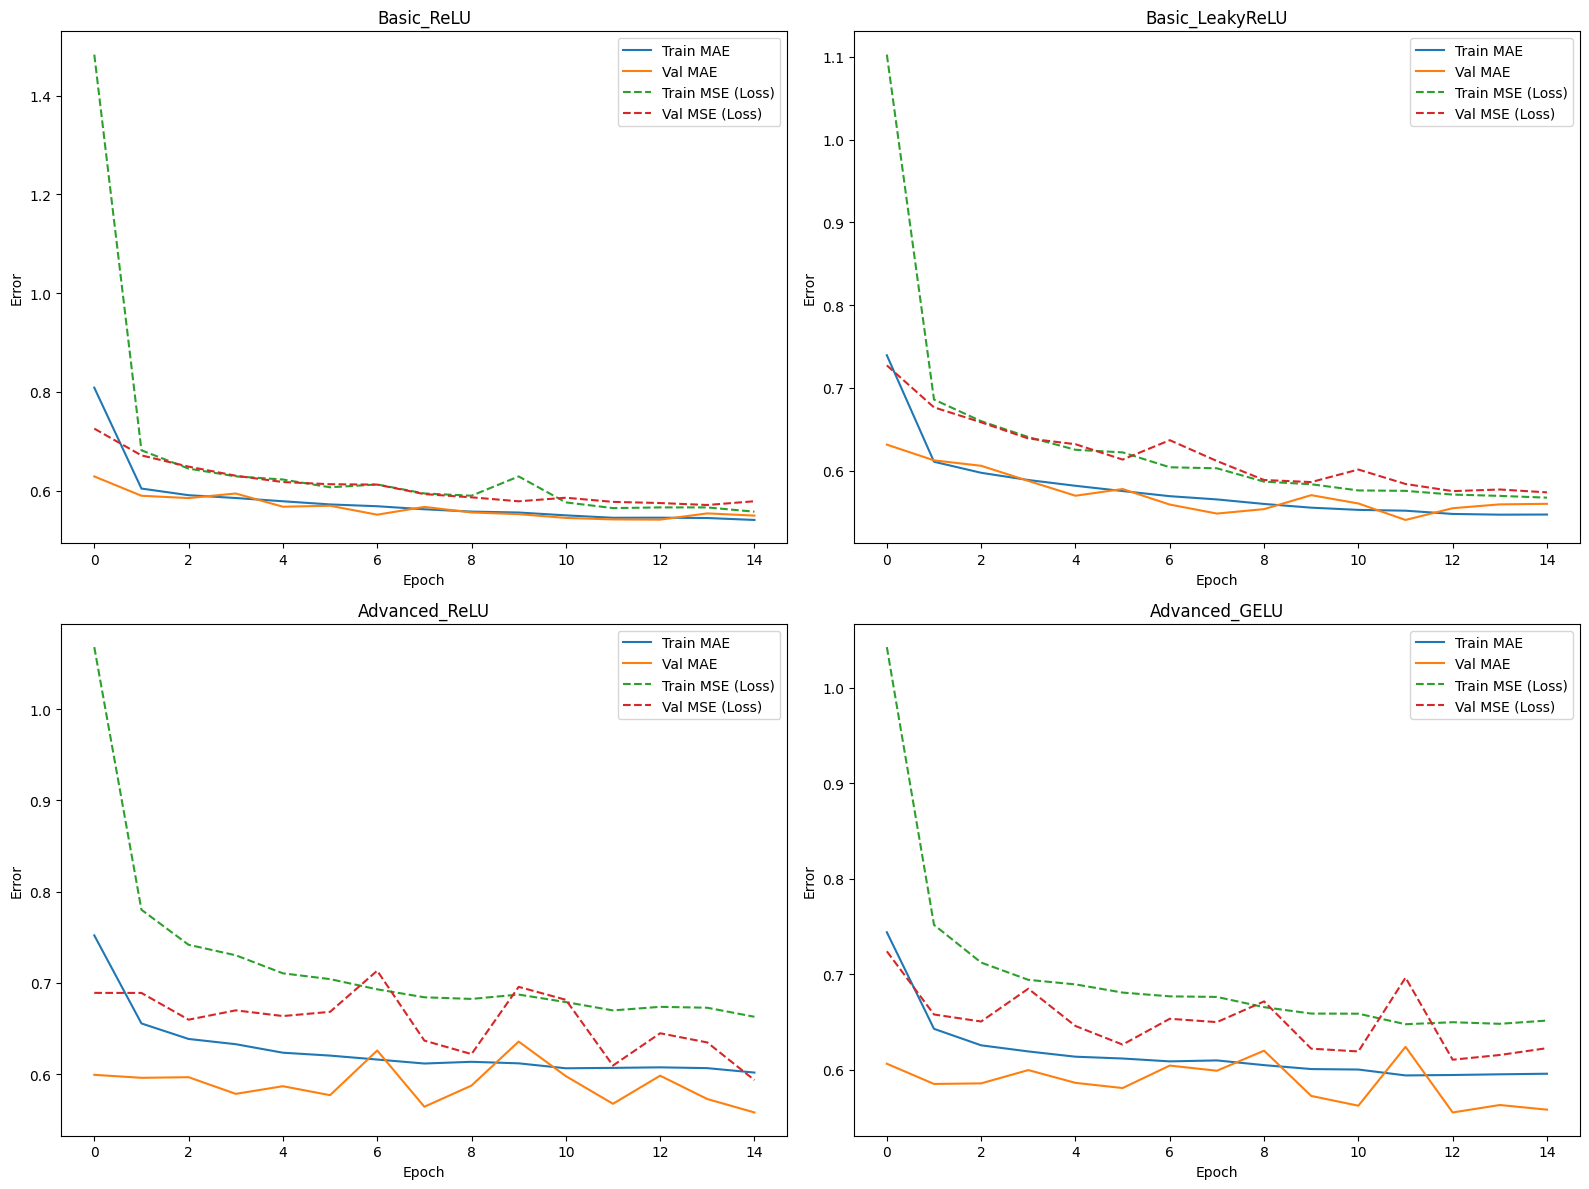

In [22]:
# --- 10. Learning Curves Visualization ---
plt.figure(figsize=(16, 12))

for i, (name, history) in enumerate(histories.items(), 1):
    plt.subplot(2, 2, i)
    
    # Access dictionary keys directly
    plt.plot(history['mae'], label='Train MAE', color='blue')
    plt.plot(history['val_mae'], label='Val MAE', color='orange')
    plt.plot(history['loss'], '--', label='Train MSE (Loss)', color='green')
    plt.plot(history['val_loss'], '--', label='Val MSE (Loss)', color='red')
    
    plt.title(f"Learning Curves: {name}")
    plt.xlabel('Epochs')
    plt.ylabel('Error Margin')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [23]:
# --- 11. Detailed Metrics Evaluation ---
print("=== Final PyTorch Metrics Overview ===\n")

for name, model in models_to_train.items():
    # 1. Evaluation mode (Disables Dropout, fixes BatchNorm)
    model.eval()
    
    # 2. Disable gradients (Improves speed & memory efficiency)
    with torch.no_grad():
        # Predict and transfer tensors back to CPU NumPy format
        y_train_pred = model(X_train_tensor.to(device)).cpu().numpy().ravel()
        y_val_pred = model(X_val_tensor.to(device)).cpu().numpy().ravel()
        y_test_pred = model(X_test_tensor.to(device)).cpu().numpy().ravel()
    
    # 3. Calculate metrics
    metrics = {}
    for split_name, y_true, y_pred in zip(
        ["Train", "Validation", "Test"],
        [y_train, y_val, y_test], # Original target arrays
        [y_train_pred, y_val_pred, y_test_pred]
    ):
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse_val = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        metrics[split_name] = (mae, mse, rmse_val, r2)
    
    # 4. Display Output
    print(f"Architecture: {name}")
    for split_name in ["Train", "Validation", "Test"]:
        mae, mse, rmse_val, r2 = metrics[split_name]
        print(f"  {split_name:<10} | MAE={mae:.4f}, MSE={mse:.4f}, RMSE={rmse_val:.4f}, R²={r2:.4f}")
    print("-" * 70)

Метрики для моделей (PyTorch):

Модель: Basic_ReLU
  Train: MAE=0.5436, MSE=0.5590, RMSE=0.7476, R²=0.5828
  Validation: MAE=0.5491, MSE=0.5776, RMSE=0.7600, R²=0.5566
  Test: MAE=0.5356, MSE=0.5417, RMSE=0.7360, R²=0.5903
------------------------------------------------------------
Модель: Basic_LeakyReLU
  Train: MAE=0.5567, MSE=0.5601, RMSE=0.7484, R²=0.5820
  Validation: MAE=0.5594, MSE=0.5727, RMSE=0.7568, R²=0.5604
  Test: MAE=0.5518, MSE=0.5495, RMSE=0.7413, R²=0.5844
------------------------------------------------------------
Модель: Advanced_ReLU
  Train: MAE=0.5632, MSE=0.7053, RMSE=0.8398, R²=0.4735
  Validation: MAE=0.5576, MSE=0.5925, RMSE=0.7697, R²=0.5452
  Test: MAE=0.5504, MSE=0.5759, RMSE=0.7589, R²=0.5644
------------------------------------------------------------
Модель: Advanced_GELU
  Train: MAE=0.5623, MSE=0.7030, RMSE=0.8384, R²=0.4753
  Validation: MAE=0.5580, MSE=0.6219, RMSE=0.7886, R²=0.5226
  Test: MAE=0.5490, MSE=0.5857, RMSE=0.7653, R²=0.5571
----------